# Eval Explorer: GCC-Eval vs Atom-Based Evaluation

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import chess
import chess.svg
import chess.engine
import openai
from stockfish import Stockfish
from IPython.display import display, Markdown, SVG

STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GENERATOR_MODEL = "gpt-5-mini"
JUDGE_MODEL = "gpt-4o"
JSONL_PATH = "../logical_chess.jsonl"

client = openai.OpenAI(api_key=OPENAI_API_KEY)


class _StockfishWrapper:
    """Auto-reinitializing wrapper around the stockfish package."""

    def __init__(self, path, **kwargs):
        self._path = path
        self._kwargs = kwargs
        self._engine = Stockfish(path=path, **kwargs)

    def _ensure_alive(self):
        try:
            self._engine.get_fen_position()
        except Exception:
            self._engine = Stockfish(path=self._path, **self._kwargs)

    def __getattr__(self, name):
        # Proxy everything to the underlying engine, with auto-reinit on crash
        attr = getattr(self._engine, name)
        if not callable(attr):
            return attr

        def wrapper(*args, **kwargs):
            try:
                return attr(*args, **kwargs)
            except Exception:
                self._engine = Stockfish(path=self._path, **self._kwargs)
                return getattr(self._engine, name)(*args, **kwargs)

        return wrapper


stockfish_engine = _StockfishWrapper(STOCKFISH_PATH)

In [2]:
DATASET = [json.loads(line) for line in open(JSONL_PATH)]
print(f"Loaded {len(DATASET)} entries")


def sample(n=1, seed=42):
    """Return n random entries. Returns a single dict when n=1."""
    rng = random.Random(seed)
    picks = rng.sample(DATASET, min(n, len(DATASET)))
    return picks[0] if n == 1 else picks


def get_entry(line_num):
    """0-indexed retrieval with bounds check."""
    if line_num < 0 or line_num >= len(DATASET):
        raise IndexError(f"line_num {line_num} out of range [0, {len(DATASET) - 1}]")
    return DATASET[line_num]


def get_entries_for_game(game_id):
    """All moves from a game."""
    return [e for e in DATASET if e.get("game_id") == game_id]

Loaded 1832 entries


In [3]:
# ---------------------------------------------------------------------------
# Stockfish analysis (rich top-3 display) — from explore-data.ipynb
# ---------------------------------------------------------------------------

def _format_score(score):
    """Format a chess.engine score from White's perspective."""
    if score.is_mate():
        return f"M{score.mate()}"
    return f"{score.score()/100:+.2f}"


def _pv_to_san(board, pv_moves):
    """Convert a list of UCI moves to a SAN string."""
    b = board.copy()
    san = []
    for m in pv_moves:
        san.append(b.san(m))
        b.push(m)
    return " ".join(san)


def stockfish_analysis(fen, played_uci, depth=20):
    """Return top-3 moves + the played move (if not in top 3) with eval and PV."""
    board = chess.Board(fen)
    played_move = chess.Move.from_uci(played_uci)
    played_san = board.san(played_move)

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        # top 3
        result = engine.analysis(board, chess.engine.Limit(depth=depth), multipv=3)
        infos = []
        for info in result:
            if "multipv" in info and info.get("depth", 0) >= depth:
                infos.append(info)
            if len(infos) == 3:
                break
        result.stop()

        # check if played move is in top 3
        top_ucis = {info["pv"][0] for info in infos if info.get("pv")}
        played_in_top3 = played_move in top_ucis

        # if not, analyse the played move specifically
        played_info = None
        if not played_in_top3:
            board_after = board.copy()
            board_after.push(played_move)
            info = engine.analyse(board_after, chess.engine.Limit(depth=depth))
            played_info = {
                "move": played_san,
                "eval": _format_score(info["score"].white()),
                "pv": played_san + " " + _pv_to_san(board_after, info.get("pv", [])),
            }

    lines = []
    for info in infos:
        score = info["score"].white()
        pv_moves = info.get("pv", [])
        move_san = board.san(pv_moves[0]) if pv_moves else "?"
        lines.append({
            "move": move_san,
            "eval": _format_score(score),
            "pv": _pv_to_san(board, pv_moves),
            "played": move_san == played_san,
        })

    return lines, played_info


# ---------------------------------------------------------------------------
# GCC engine evaluation helper — from eval-pipeline.ipynb
# ---------------------------------------------------------------------------

engine_cache = {}

def _get_engine_evaluation_inner(fen, target_move):
    """Core logic — may raise if the stockfish process dies mid-sequence."""
    depth = 20

    stockfish_engine.set_fen_position(fen)
    best_moves = stockfish_engine.get_top_moves(2)
    stockfish_engine.set_depth(depth + 1)
    eval1 = stockfish_engine.get_evaluation()

    stockfish_engine.set_depth(depth + 1)
    target_move_san = target_move.split(" ")[0]
    board = chess.Board(fen)
    uci_text = board.copy().push_san(target_move_san).uci()
    stockfish_engine.make_moves_from_current_position([uci_text])
    eval2 = stockfish_engine.get_evaluation()
    move_score = f"Mate in {eval2['value'] * -1}" if eval2['type'] == "mate" else f"{eval2['value'] * -1}cp"
    if move_score == "Mate in 0":
        move_score = "Checkmate!"
    if "Mate" not in move_score:
        best_reply = stockfish_engine.get_best_move()
        move_score = f"{move_score}, expected reply - {best_reply}"

    best_move1 = board.copy().san(board.copy().push_uci(best_moves[0]['Move']))
    if best_moves[0]['Mate'] is not None:
        best_score1 = f"Mate in {best_moves[0]['Mate'] - 1}"
        if best_score1 == "Mate in 0":
            best_score1 = "Checkmate!"
    else:
        if "cp" in move_score:
            diff = best_moves[0]['Centipawn'] - eval2['value'] * -1
            if diff < 20:
                best_score1 = "similar to actual move"
            elif diff < 50:
                best_score1 = "better than actual move over 20cp"
            elif diff < 100:
                best_score1 = "better than actual move over 50cp"
            else:
                best_score1 = "better than actual move over 100cp, worth a pawn"
        else:
            best_score1 = f"{best_moves[0]['Centipawn']}cp"

    if len(best_moves) == 1:
        return f"evaluation: only legal move; move - {target_move_san} {move_score}"

    best_move2 = board.copy().san(board.copy().push_uci(best_moves[1]['Move']))
    if best_moves[1]['Mate'] is not None:
        best_score2 = f"Mate in {best_moves[1]['Mate'] - 1}"
        if best_score2 == "Mate in 0":
            best_score2 = "Checkmate!"
    else:
        if "cp" in move_score:
            diff = best_moves[1]['Centipawn'] - eval2['value'] * -1
            if diff < 20:
                best_score2 = "similar to actual move"
            elif diff < 50:
                best_score2 = "better than actual move over 20cp"
            elif diff < 100:
                best_score2 = "better than actual move over 50cp"
            else:
                best_score2 = "better than actual move over 100cp, worth a pawn"
        else:
            best_score2 = f"{best_moves[1]['Centipawn']}cp"

    return f"evaluation: actual move - {target_move_san} {move_score}, best move - {best_move1} {best_score1}, second best move - {best_move2} {best_score2}"


def get_engine_evaluation(fen, target_move):
    """GCC-style engine evaluation string. Auto-retries on Stockfish crash."""
    key = f"{fen} {target_move}"
    if key in engine_cache:
        return engine_cache[key]

    for attempt in range(3):
        try:
            eval_str = _get_engine_evaluation_inner(fen, target_move)
            engine_cache[key] = eval_str
            return eval_str
        except Exception as e:
            if attempt == 2:
                return f"evaluation: error - {e}"
            # _StockfishWrapper will auto-reinit on next call


# ---------------------------------------------------------------------------
# Interpretable features — from eval-pipeline.ipynb
# ---------------------------------------------------------------------------

def get_interpretable_features(fen, move_uci):
    """Extract interpretable features for a position + move."""
    try:
        board = chess.Board(fen)
        move = chess.Move.from_uci(move_uci)

        san = board.san(move)
        is_capture = board.is_capture(move)

        board.push(move)

        is_check = board.is_check()

        piece_square = move.to_square
        attacks = list(board.attacks(piece_square))
        controlled_squares = [chess.square_name(s) for s in attacks]

        with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
            info = engine.analyse(board, chess.engine.Limit(depth=15))
            score = info["score"].white().score(mate_score=10000)

            board.pop()
            best_info = engine.analyse(board, chess.engine.Limit(depth=15))
            best_score = best_info["score"].white().score(mate_score=10000)
            score_diff = score - best_score

        return {
            "move_san": san,
            "is_capture": is_capture,
            "gives_check": is_check,
            "squares_controlled": controlled_squares,
            "eval_centipawns": score,
            "is_optimal": score_diff > -30,
            "is_blunder": score_diff < -200
        }
    except Exception as e:
        return {"error": str(e)}

In [4]:
def extract_golden_atoms(golden_text):
    prompt = f"""
    You are a chess expert, your task is to break down the following chess commentary into a list of Atomic Facts (e.g. strategic goals, tactical threats, or variations), each item must be a distinct verifiable claim.
    Output pure JSON list of strings.
    
    Commentary: "{golden_text}"
    Output Format: {{"atoms": ["fact1", "fact2"]}}
    """
    system_instruction = """
    You are an Expert Chess Benchmark Creator.
    Your goal is to extract a "Grading Rubric" from human expert commentary to evaluate AI models.
    
    CRITICAL RULES:
    1. Extract ONLY facts related to the **strategic logic, tactics, or evaluation** of the current move/position.
    2. IGNORE non-game content:
       - Historical anecdotes ("In the Parisian Café...", "Deschapelles asserted...")
       - Player biographies or names ("Morphy played this...", "La Bourdonnais..."), or tournament/venue details.
       - Raw notation, a list of algebraic moves (e.g., "4... Nxd4 5. Qxd4 e6").
       - Quotes about other games or generic chess philosophy not applied to this specific board state.
    3. If a sentence mixes history and strategy (e.g., "Fischer played h6 to create luft"), extract ONLY the strategy ("h6 creates luft").
    4. If the commentary contains NO relevant strategic analysis of the current board state, return an empty list [].
    
    OUTPUT FORMAT:
        You must return a valid JSON object with a single key "atoms", which is a list of strings.
        Example: {"atoms": ["Nf3 develops the knight", "Nf3 controls d4"]}
    """
    demos = [
            {
                "text": "The move Nf3 is a standard developing move that controls the center.",
                "atoms": [
                    "Nf3 is a developing move.",
                    "Nf3 controls the center."
                ]
            },
            {
                "text": "In the Parisian Café de la Régence they preferred 2 f4. McDonnell several times played this against La Bourdonnais, but the Frenchman was more successful.",
                "atoms": [] 
            },
            {
                "text": "Although Staunton disliked this, 2... Nc6 develops the knight to a natural square and prepares to fight for d4.",
                "atoms": [
                    "2... Nc6 develops the knight.",
                    "The knight goes to a natural square.",
                    "2... Nc6 prepares to fight for d4."
                ]
            }
        ]
    prompt_text = "Task: Extract the strategic atomic facts for the grading rubric.\n\n"
        
    for demo in demos:
        prompt_text += f"Input: \"{demo['text']}\"\n"
        prompt_text += f"Output: {json.dumps(demo['atoms'])}\n\n"
        
    prompt_text += f"Input: \"{golden_text}\"\nOutput:"
    
    response = client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[{"role": "system", "content": system_instruction},
                  {"role": "user", "content": prompt_text}],
        response_format={"type": "json_object"}
    )
    try:
        data = json.loads(response.choices[0].message.content)
        return data.get("atoms", []) 
    except:
        return [golden_text] 

In [5]:
def get_gcc_baseline_score(fen, move, candidate, reference, engine_eval):
    """GCC-Eval relevance score (1-5) via logprob-weighted expectation."""
    system_prompt = """You will be given two comments about a chess move.
    Your task is to rate the comment on one metric.
    Please make sure you read and understand these instructions carefully.

    Evaluation Criteria:
    Relevance (1-5) - Relevence of the target comment to important aspects of the chess move. The comment should include only information relevant to the chess move or reasoning for taking or not taking the chess move. An engine evaluation result and a reference comment is given as a hint.

    Evaluation Steps:
    1. Read the commment and the reference comment carefully.
    2. Read the chess position and move carefully, and find out important aspects based on the reference.
    3. Assess if every expressen of the comment is relevant to the important information about the chess move.
    4. Assign a Relevance score from 1 to 5.
    """

    user_prompt = f"""position:
    {fen}

    move:
    {move}

    target comment:
    {candidate}

    reference comment:
    {reference}

    engine evaluation:
    {engine_eval}

    Score(1-5, score ONLY): """

    response = client.chat.completions.create(
        model=JUDGE_MODEL,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=1,
        logprobs=True,
        top_logprobs=5,
        temperature=0.0
    )

    top_logprobs = response.choices[0].logprobs.content[0].top_logprobs

    score_map = {str(i): 0.0 for i in range(1, 6)}
    total_prob = 0.0

    for item in top_logprobs:
        token = item.token.strip()
        if token in score_map:
            prob = np.exp(item.logprob)
            score_map[token] = prob
            total_prob += prob

    if total_prob == 0:
        return 1.0

    weighted_score = sum(int(k) * (v / total_prob) for k, v in score_map.items())
    return weighted_score

In [6]:

def get_weighted_score(fen, move, candidate, golden_atoms, engine_features, metric="Precision"):
    
    system_prompts = {}
    
    system_prompts["Precision"] = """You will be given a generated comment about a chess move, a list of verified reference atoms (golden atoms), and explicit engine features.
    Your task is to rate the comment on the Precision metric.
    Please make sure you read and understand these instructions carefully.
    
    Evaluation Criteria:
    Precision (1-5) - The degree to which the generated comment avoids hallucinations and irrelevant information. The comment should only include statements that are factually supported by the golden atoms or the explicit engine features. 
    
    Evaluation Steps:
    1. Read the generated comment, the golden atoms, and the engine features carefully.
    2. Identify the specific strategic and tactical claims made in the generated comment.
    3. Check each claim against the golden atoms and engine features. Penalize the score heavily if the comment contains unsupported claims, mentions non-existent pieces, or hallucinates strategic ideas.
    4. Assign a Precision score from 1 to 5 (1 = highly hallucinated/incorrect, 5 = all claims strictly supported by the provided facts).
    """

    system_prompts["Recall"] = """You will be given a generated comment about a chess move, a list of verified reference atoms (golden atoms), and explicit engine features.
    Your task is to rate the comment on the Recall metric.
    Please make sure you read and understand these instructions carefully.
    
    Evaluation Criteria:
    Recall (1-5) - The degree to which the generated comment covers the critical information. The comment should address all the important strategic points and tactical facts present in the golden atoms and engine features.
    
    Evaluation Steps:
    1. Read the golden atoms and engine features carefully to understand the core tactical and strategic elements of the given position.
    2. Read the generated comment.
    3. Assess how many of the crucial golden atoms and engine features are successfully mentioned, explained, or addressed in the generated comment. Penalize the score if key concepts are omitted.
    4. Assign a Recall score from 1 to 5 (1 = misses most/all key points, 5 = covers all critical points comprehensively).
    """

    user_prompt = f"""position:
    {fen}

    move:
    {move}

    target comment:
    {candidate}

    golden atoms:
    {golden_atoms}

    engine features:
    {engine_features}

    Score(1-5, score ONLY): """

    response = client.chat.completions.create(
        model=JUDGE_MODEL, 
        messages=[
            {"role": "system", "content": system_prompts[metric]},
            {"role": "user", "content": user_prompt}
        ],
        max_tokens=1,
        logprobs=True,
        top_logprobs=5,
        temperature=0.0
    )

    top_logprobs = response.choices[0].logprobs.content[0].top_logprobs
    
    score_map = {str(i): 0.0 for i in range(1, 6)}
    total_prob = 0.0
    
    for item in top_logprobs:
        token = item.token.strip()
        if token in score_map:
            prob = np.exp(item.logprob)
            score_map[token] = prob
            total_prob += prob
            
    if total_prob == 0: return 1.0
        
    weighted_score = sum(int(k) * (v / total_prob) for k, v in score_map.items())
    
    return weighted_score

# p_score = get_weighted_score(fen, move, target_comment, golden_atoms, engine_feats, "Precision")
# r_score = get_weighted_score(fen, move, target_comment, golden_atoms, engine_feats, "Recall")
        

# print(f"Relevance Score: {p_score:.4f}")
# print(f"Completeness Score: {r_score:.4f}")


In [7]:
def generate_candidate_explanation(fen, move_uci, model=None):
    """Generate a candidate explanation for a chess move."""
    model = model or GENERATOR_MODEL
    board = chess.Board(fen)
    move_san = board.san(chess.Move.from_uci(move_uci))

    system_prompt = "You are a helpful chess tutor. Explain the strategic reason for the given move."
    user_prompt = f"Position FEN: {fen}\nMove: {move_san}\nExplain this move:"

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"Error generating: {str(e)}"

In [8]:
def inspect(entry, candidate=None, generate=False):
    """Display everything for one position. Optionally generate + score.

    Returns a dict with all computed values for programmatic use.
    """
    fen = entry["fen"]
    move_san = entry["move_san"]
    move_uci = entry["move_uci"]
    annotation = entry["annotation"]
    meta = entry.get("metadata", {})

    result = {
        "fen": fen,
        "move_san": move_san,
        "move_uci": move_uci,
        "annotation": annotation,
    }

    # --- Header ---
    white = meta.get("White", "?")
    black = meta.get("Black", "?")
    event = meta.get("Event", "")
    date = meta.get("Date", "")
    header = f"**{white} vs {black}**"
    if event:
        header += f" | {event}"
    if date:
        header += f" ({date})"
    display(Markdown(header))

    # --- Board SVG ---
    board = chess.Board(fen)
    move_obj = chess.Move.from_uci(move_uci)
    svg = chess.svg.board(board, arrows=[(move_obj.from_square, move_obj.to_square)], size=400)
    display(SVG(svg))

    # --- Move info ---
    display(Markdown(f"**Move:** {move_san} (`{move_uci}`)  \n**FEN:** `{fen}`"))

    # --- Stockfish top-3 ---
    display(Markdown("### Stockfish Top 3"))
    top3, played_info = stockfish_analysis(fen, move_uci)
    result["top3"] = top3
    result["played_info"] = played_info
    for i, line in enumerate(top3, 1):
        tag = " **(played)**" if line["played"] else ""
        display(Markdown(f"{i}. **{line['move']}** ({line['eval']}){tag}  \n   PV: {line['pv']}"))
    if played_info:
        display(Markdown(
            f"**Played move not in top 3 — {played_info['move']}** ({played_info['eval']})  \n"
            f"PV: {played_info['pv']}"
        ))

    # --- Golden annotation ---
    display(Markdown(f"### Golden Annotation\n> {annotation}"))

    # --- Golden atoms ---
    atoms = extract_golden_atoms(annotation)
    result["atoms"] = atoms
    display(Markdown("### Golden Atoms"))
    for i, atom in enumerate(atoms, 1):
        display(Markdown(f"{i}. {atom}"))

    # --- Candidate generation + scoring ---
    if generate and candidate is None:
        candidate = generate_candidate_explanation(fen, move_uci)

    if candidate is not None:
        result["candidate"] = candidate
        display(Markdown(f"### Candidate Explanation\n{candidate}"))

        # Engine eval for GCC
        engine_eval = get_engine_evaluation(fen, move_san)
        result["engine_eval"] = engine_eval

        # GCC score
        gcc_score = get_gcc_baseline_score(fen, move_san, candidate, annotation, engine_eval)
        result["gcc_score"] = gcc_score

        # Atom scores (Precision + Recall)
        engine_features = get_interpretable_features(fen, move_uci)
        result["engine_features"] = engine_features
        precision = get_weighted_score(fen, move_san, candidate, atoms, engine_features, metric="Precision")
        recall = get_weighted_score(fen, move_san, candidate, atoms, engine_features, metric="Recall")
        result["precision"] = precision
        result["recall"] = recall

        delta_p = precision - gcc_score
        delta_r = recall - gcc_score
        result["delta_p"] = delta_p
        result["delta_r"] = delta_r

        display(Markdown(
            f"### Scores\n"
            f"**GCC: {gcc_score:.2f} | Precision: {precision:.2f} (Δ {delta_p:+.2f}) | Recall: {recall:.2f} (Δ {delta_r:+.2f})**"
        ))

    return result

**Chekhover vs Rudakowsky** | Moscow (1945.??.??)

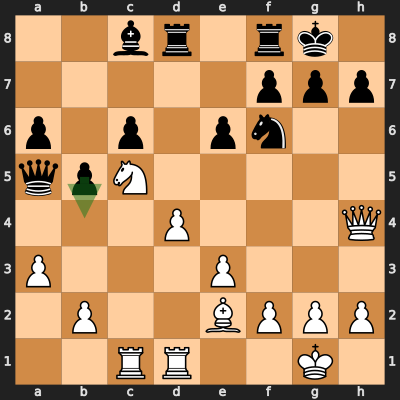

**Move:** b4 (`b5b4`)  
**FEN:** `2br1rk1/5ppp/p1p1pn2/qpN5/3P3Q/P3P3/1P2BPPP/2RR2K1 b - - 0 21`

### Stockfish Top 3

1. **Qc7** (+2.19)  
   PV: Qc7 Qg3 Qxg3 hxg3 Nd5 Rc2 f6 Bg4 Kf7 Rdc1 Ke7 Nb3 e5 Bxc8

2. **Qb6** (+2.26)  
   PV: Qb6 Bf3 a5 Nd3 Bd7 Rc5 Nd5 Ne5 f6 Nxd7 Rxd7 Qe4 Rd6 Qc2 Rfd8

3. **h6** (+2.27)  
   PV: h6 Bf3 Qb6 Nd3 Nd5 Ne5 Bd7 Rc5 f6 Ng6 Rf7 Rdc1 Be8 Qg3 Ne7

**Played move not in top 3 — b4** (+2.45)  
PV: b4 a4 Nd7 Bd3 g6 Ne4 Kg7 b3 h6 Nc5 Nxc5 Rxc5 Qc7 Rdc1

### Golden Annotation
> Hoping to disrupt White’s queenside by continuing with 22...bxa3.

### Golden Atoms

1. 22...bxa3 aims to disrupt White’s queenside.

{'fen': '2br1rk1/5ppp/p1p1pn2/qpN5/3P3Q/P3P3/1P2BPPP/2RR2K1 b - - 0 21',
 'move_san': 'b4',
 'move_uci': 'b5b4',
 'annotation': 'Hoping to disrupt White’s queenside by continuing with 22...bxa3.',
 'top3': [{'move': 'Qc7',
   'eval': '+2.19',
   'pv': 'Qc7 Qg3 Qxg3 hxg3 Nd5 Rc2 f6 Bg4 Kf7 Rdc1 Ke7 Nb3 e5 Bxc8',
   'played': False},
  {'move': 'Qb6',
   'eval': '+2.26',
   'pv': 'Qb6 Bf3 a5 Nd3 Bd7 Rc5 Nd5 Ne5 f6 Nxd7 Rxd7 Qe4 Rd6 Qc2 Rfd8',
   'played': False},
  {'move': 'h6',
   'eval': '+2.27',
   'pv': 'h6 Bf3 Qb6 Nd3 Nd5 Ne5 Bd7 Rc5 f6 Ng6 Rf7 Rdc1 Be8 Qg3 Ne7',
   'played': False}],
 'played_info': {'move': 'b4',
  'eval': '+2.45',
  'pv': 'b4 a4 Nd7 Bd3 g6 Ne4 Kg7 b3 h6 Nc5 Nxc5 Rxc5 Qc7 Rdc1'},
 'atoms': ['22...bxa3 aims to disrupt White’s queenside.']}

In [61]:
entry = sample(seed=42)
inspect(entry)                    # dataset QA — no API cost (except atom extraction)

**Colle vs Delvaux** | Gand-Terneuen (1929.??.??)

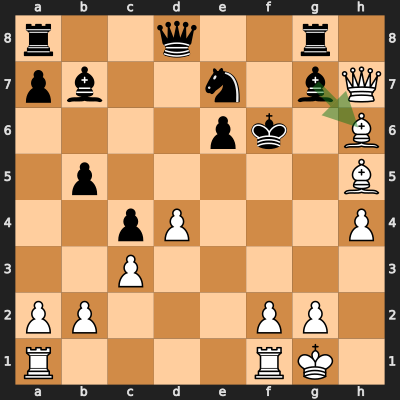

**Move:** Bxh6 (`g7h6`)  
**FEN:** `r2q2r1/pb2n1bQ/4pk1B/1p5B/2pP3P/2P5/PP3PP1/R4RK1 b - - 0 21`

### Stockfish Top 3

1. **e5** (+7.39)  
   PV: e5 Bxg7+ Rxg7 dxe5+ Ke6 Qxg7 Qf8 Bg4+ Kd5 Qg5 Kc6 Rad1 Re8 Qe3 Kc7 Rd7+ Kb8 Rxb7+ Kxb7 Rd1 Rd8 Rxd8 Qxd8 Qe4+ Ka6

2. **Qd5** (+8.35)  
   PV: Qd5 Bg5+ Qxg5 hxg5+ Kxg5 f4+ Kf6 Rfe1 Bxg2 Kxg2 Raf8 Re5 Rh8 Qe4 Rxh5 Rxh5 Rb8 Qe5+ Kf7 Qxb8 b4 Rh7 Nf5 Rg1 bxc3 bxc3 a6 Qc7+ Kg8

3. **Qxd4** (+11.38)  
   PV: Qxd4 cxd4 e5 Bxg7+ Rxg7 dxe5+ Ke6 Qxg7 Kd7 Rfd1+ Kc7 Qxe7+ Kb6 Rd6+ Bc6 Rxc6+ Kxc6 Bf3+ Kb6 Bxa8 b4 Qb7+ Ka5 Kh1 c3 Qxa7+ Kb5

...

1. 21...e5 loses a rook after 22 Bxg7+ Rxg7 23 dxe5+.

### Candidate Explanation
There are two connected ideas behind 21...Bxh6.

1) Neutralise White’s most dangerous attacker. The bishop on h6 is one of the two pieces stabbing at Black’s king; exchanging it reduces the pressure immediately.

2) It is a tactical shot that wins or gains decisive counter‑play if White recaptures. After
21...Bxh6 22.Qxh6 Black has the knockout idea
22...Rxg2+!
The rook on g2 cannot be taken by the king (Kxg2 is illegal) because White’s king would be walking into a check from Black’s bishop on b7 (that diagonal b7–g2 is decisive). White must step the king to h1 and Black’s pieces (rook(s), knight e7–f5, queen and remaining bishop) flood in along the g‑file and the long diagonals. In short, Bxh6 either trades off White’s key attacker and so soothes Black’s king, or — if White accepts — it launches a tactical sequence (Rxg2+) that wins material or destroys White’s king safety. That is why the capture is played.

### Atom-Based Reasoning
The candidate explanation did not address the Golden Atoms because it did not mention the potential consequence of playing 21...e5, which could result in losing a rook after 22 Bxg7+ Rxg7 23 dxe5+. However, the explanation did align with the Engine Facts, as it accurately described 21...Bxh6 as part of a tactical sequence that trades off a key attacker and can lead to significant material gain for Black. The candidate did not contradict any evaluative points from the Engine Facts, such as the move being a capture, not giving check immediately, and being an optimal play without being a blunder. Overall, while the candidate's explanation did capture the tactical benefits of the move, it overlooked a critical alternative scenario highlighted by the Golden Atoms.

### Scores
**GCC: 4.02 | Atom: 3.06 | Delta: -0.96**

{'fen': 'r2q2r1/pb2n1bQ/4pk1B/1p5B/2pP3P/2P5/PP3PP1/R4RK1 b - - 0 21',
 'move_san': 'Bxh6',
 'move_uci': 'g7h6',
 'annotation': 'Loses on the spot, but there was no defence for Black: if 21... e5, then 22 Bxg7+ Rxg7 23 dxe5+ and the king must abandon the rook.',
 'top3': [{'move': 'e5',
   'eval': '+7.39',
   'pv': 'e5 Bxg7+ Rxg7 dxe5+ Ke6 Qxg7 Qf8 Bg4+ Kd5 Qg5 Kc6 Rad1 Re8 Qe3 Kc7 Rd7+ Kb8 Rxb7+ Kxb7 Rd1 Rd8 Rxd8 Qxd8 Qe4+ Ka6',
   'played': False},
  {'move': 'Qd5',
   'eval': '+8.35',
   'pv': 'Qd5 Bg5+ Qxg5 hxg5+ Kxg5 f4+ Kf6 Rfe1 Bxg2 Kxg2 Raf8 Re5 Rh8 Qe4 Rxh5 Rxh5 Rb8 Qe5+ Kf7 Qxb8 b4 Rh7 Nf5 Rg1 bxc3 bxc3 a6 Qc7+ Kg8',
   'played': False},
  {'move': 'Qxd4',
   'eval': '+11.38',
   'pv': 'Qxd4 cxd4 e5 Bxg7+ Rxg7 dxe5+ Ke6 Qxg7 Kd7 Rfd1+ Kc7 Qxe7+ Kb6 Rd6+ Bc6 Rxc6+ Kxc6 Bf3+ Kb6 Bxa8 b4 Qb7+ Ka5 Kh1 c3 Qxa7+ Kb5',
   'played': False}],
 'played_info': {'move': 'Bxh6', 'eval': 'M1', 'pv': 'Bxh6 Qf7#'},
 'atoms': ['21...e5 loses a rook after 22 Bxg7+ Rxg7 23 dxe5+.'],
 'candidate

In [45]:
entry = sample(seed=123)
inspect(entry, generate=True)    # full pipeline with scoring

**Tarrasch vs Mieses** | Berlin (1916.??.??)

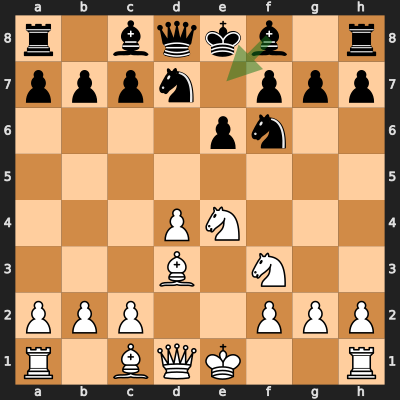

**Move:** Be7 (`f8e7`)  
**FEN:** `r1bqkb1r/pppn1ppp/4pn2/8/3PN3/3B1N2/PPP2PPP/R1BQK2R b KQkq - 4 6`

### Stockfish Top 3

1. **c5** (+0.36)  
   PV: c5 Nxf6+ Nxf6 Be3 Qc7 Qe2 a6 O-O-O b5 dxc5 Bxc5 Bxc5 Qxc5 Rhe1 O-O Ne5 Bb7 g4 Rad8 g5 Nd5 Qh5 g6 Qh4 Nb4 Kb1 Rd4

2. **Nxe4** (+0.38)  
   PV: Nxe4 Bxe4 Nf6 Bd3 c5 Be3 Qc7 Qe2 a6 O-O-O b5 dxc5 Bxc5 Bxc5 Qxc5 Rhe1 Bb7 Ne5 Qc7 Kb1 O-O

3. **a6** (+0.62)  
   PV: a6 Qe2 Nxe4 Bxe4 Nf6 Bg5 Be7 Bxf6 gxf6 O-O f5 Bd3 Kf8 Rfd1 Bf6 c4 Bg7 c5

**Played move not in top 3 — Be7** (+0.64)  
PV: Be7 Qe2 Nxe4 Qxe4 c5 O-O Nf6 Qh4 cxd4 Re1 b6 Nxd4 Bb7 Bg5 Qd5 Nf3 h6 Rad1

### Golden Annotation
> The bishop is well placed at e7, and the decks are cleared for early kingside castling.
6... Nxe4 7 Bxe4 Nf6 8 Bd3 is an interesting alternative, when the time lost by the bishop’s retreat compensates Black for the tempo he lost when he played 3...dxe4.

### Golden Atoms

1. The bishop is well placed at e7, clearing the path for kingside castling.

{'fen': 'r1bqkb1r/pppn1ppp/4pn2/8/3PN3/3B1N2/PPP2PPP/R1BQK2R b KQkq - 4 6',
 'move_san': 'Be7',
 'move_uci': 'f8e7',
 'annotation': 'The bishop is well placed at e7, and the decks are cleared for early kingside castling.\n6... Nxe4 7 Bxe4 Nf6 8 Bd3 is an interesting alternative, when the time lost by the bishop’s retreat compensates Black for the tempo he lost when he played 3...dxe4.',
 'top3': [{'move': 'c5',
   'eval': '+0.36',
   'pv': 'c5 Nxf6+ Nxf6 Be3 Qc7 Qe2 a6 O-O-O b5 dxc5 Bxc5 Bxc5 Qxc5 Rhe1 O-O Ne5 Bb7 g4 Rad8 g5 Nd5 Qh5 g6 Qh4 Nb4 Kb1 Rd4',
   'played': False},
  {'move': 'Nxe4',
   'eval': '+0.38',
   'pv': 'Nxe4 Bxe4 Nf6 Bd3 c5 Be3 Qc7 Qe2 a6 O-O-O b5 dxc5 Bxc5 Bxc5 Qxc5 Rhe1 Bb7 Ne5 Qc7 Kb1 O-O',
   'played': False},
  {'move': 'a6',
   'eval': '+0.62',
   'pv': 'a6 Qe2 Nxe4 Bxe4 Nf6 Bg5 Be7 Bxf6 gxf6 O-O f5 Bd3 Kf8 Rfd1 Bf6 c4 Bg7 c5',
   'played': False}],
 'played_info': {'move': 'Be7',
  'eval': '+0.64',
  'pv': 'Be7 Qe2 Nxe4 Qxe4 c5 O-O Nf6 Qh4 cxd4 Re1 b6 Nxd4 Bb7

In [11]:
entry = get_entry(500)
inspect(entry)                   # by line number

In [63]:
def scan(n=50, seed=42, model=None):
    """Batch: generate + score n random entries, displaying the full inspect() output for each."""
    entries = sample(n=n, seed=seed) if n > 1 else [sample(seed=seed)]
    results = []

    for idx, entry in enumerate(entries):
        display(Markdown(f"---\n## [{idx+1}/{n}] {entry.get('game_id', '')}"))
        try:
            r = inspect(entry, generate=True)
            results.append(r)
        except Exception as e:
            display(Markdown(f"**Error:** {e}"))

    display(Markdown(f"---\n**Done. {len(results)}/{n} entries scored.**"))
    return results

In [62]:
def inspect_row(df, idx):
    """Drill from scan DataFrame into full inspect() view without re-calling generation APIs."""
    row = df.iloc[idx]
    entry = get_entry(int(row["line_num"]))
    return inspect(entry, candidate=row["candidate"])


def evaluate(fen, move_uci, explanation, reference=None):
    """Score your own explanation for any position.

    Args:
        fen: FEN string
        move_uci: move in UCI format (e.g. "e2e4")
        explanation: your candidate explanation text
        reference: optional golden annotation (if from dataset). If None, skips GCC.
    """
    board = chess.Board(fen)
    move_obj = chess.Move.from_uci(move_uci)
    move_san = board.san(move_obj)

    # Board
    svg = chess.svg.board(board, arrows=[(move_obj.from_square, move_obj.to_square)], size=400)
    display(SVG(svg))
    display(Markdown(f"**Move:** {move_san} (`{move_uci}`)  \n**FEN:** `{fen}`"))

    # Stockfish top-3
    display(Markdown("### Stockfish Top 3"))
    top3, played_info = stockfish_analysis(fen, move_uci)
    for i, line in enumerate(top3, 1):
        tag = " **(played)**" if line["played"] else ""
        display(Markdown(f"{i}. **{line['move']}** ({line['eval']}){tag}  \n   PV: {line['pv']}"))
    if played_info:
        display(Markdown(
            f"**Played move not in top 3 — {played_info['move']}** ({played_info['eval']})  \n"
            f"PV: {played_info['pv']}"
        ))

    # Candidate
    display(Markdown(f"### Your Explanation\n{explanation}"))

    result = {"fen": fen, "move_san": move_san, "move_uci": move_uci, "candidate": explanation}

    # GCC score (only if reference provided)
    if reference is not None:
        display(Markdown(f"### Reference Annotation\n> {reference}"))
        engine_eval = get_engine_evaluation(fen, move_san)
        gcc_score = get_gcc_baseline_score(fen, move_san, explanation, reference, engine_eval)
        result["gcc_score"] = gcc_score

        atoms = extract_golden_atoms(reference)
    else:
        gcc_score = None
        atoms = []
        display(Markdown("*No reference provided — skipping GCC-Eval and atom extraction.*"))

    # Atom scores (only if we have atoms)
    if atoms:
        display(Markdown("### Golden Atoms"))
        for i, atom in enumerate(atoms, 1):
            display(Markdown(f"{i}. {atom}"))

        engine_features = get_interpretable_features(fen, move_uci)
        precision = get_weighted_score(fen, move_san, explanation, atoms, engine_features, metric="Precision")
        recall = get_weighted_score(fen, move_san, explanation, atoms, engine_features, metric="Recall")
        result["atoms"] = atoms
        result["precision"] = precision
        result["recall"] = recall

        if gcc_score is not None:
            delta_p = precision - gcc_score
            delta_r = recall - gcc_score
            result["delta_p"] = delta_p
            result["delta_r"] = delta_r
            display(Markdown(
                f"### Scores\n"
                f"**GCC: {gcc_score:.2f} | Precision: {precision:.2f} (Δ {delta_p:+.2f}) | Recall: {recall:.2f} (Δ {delta_r:+.2f})**"
            ))
        else:
            display(Markdown(f"### Scores\n**Precision: {precision:.2f} | Recall: {recall:.2f}**"))

    return result

---
## [1/5] LogicalChess_Game25

**Janowsky vs Alapin** | Barmen (1905.??.??)

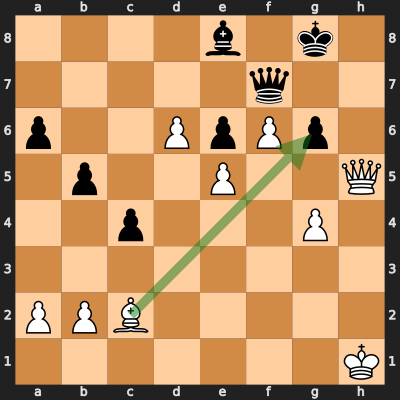

**Move:** Bxg6 (`c2g6`)  
**FEN:** `4b1k1/5q2/p2PpPp1/1p2P2Q/2p3P1/8/PPB5/7K w - - 4 45`

### Stockfish Top 3

1. **Bxg6** (+7.60) **(played)**  
   PV: Bxg6 Qxg6 Qxg6+ Bxg6 d7 Kh7 d8=Q Kh6 Qd2+ Kh7 Kg1 Bd3 Kf2 b4 Kg1 c3 bxc3

2. **Qxg6+** (+5.87)  
   PV: Qxg6+ Qxg6 Bxg6 Bd7 Kg2 b4 Kf2 a5 Ke3 b3 axb3 cxb3 Kd4 a4 Kc3 Bc6 g5 Kh8 Kb4 Bd7 Kc5 Kg8 Bb1 a3 bxa3 Kf7 Kb6

3. **Qh6** (+5.48)  
   PV: Qh6 Qb7+ Kg1 b4 Bxg6 Qa7+ Kf1 b3 Bxe8 bxa2 f7+ Qxf7+ Bxf7+ Kxf7 Qh7+ Kf8 Qe7+ Kg8

...

1. White sacrifices a piece to create a position where the passed pawns will be decisive.

### Candidate Explanation
Bxg6 is a typical decoy/undermining sacrifice aimed at demolishing Black’s last pawn shield around the king and opening lines for White’s heavy pieces.

Concrete ideas behind the move:
- It removes the g6 pawn — the key defender of Black’s king — and at the same time attacks Black’s queen on f7. Black is forced to react immediately.
- Black cannot reply Qxf6 to try to win back material, because  Qxf6?  exf6! would simply win the queen (the e‑pawn captures on f6 and the queen is lost).
- If Black captures on g6 (…Qxg6), White gets strong infiltration possibilities with the queen (Qxg6+ tactics), and Black’s kingside becomes permanently exposed. Even if material gets traded, White’s d6/f6 pawns and open lines around Black’s king give White a powerful continuing initiative.

So strategically Bxg6 is not a random sacrifice: it’s a forcing way to destroy Black’s pawn cover, either winning material by tactical motifs (see Qxf6 refutation) or opening decisive attacking lines against the exposed Black king.

### Scores
**GCC: 4.99 | Precision: 1.96 (Δ -3.03) | Recall: 3.80 (Δ -1.19)**

---
## [2/5] LogicalChess_Game9

**Znosko-Borovsky vs Mackenzie** | Weston-Super-Mare (1924.??.??)

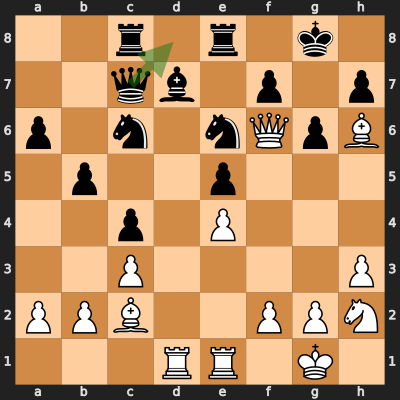

**Move:** Qd8 (`c7d8`)  
**FEN:** `2r1r1k1/2qb1p1p/p1n1nQpB/1p2p3/2p1P3/2P4P/PPB2PPN/3RR1K1 b - - 13 28`

### Stockfish Top 3

1. **Nb8** (+3.77)  
   PV: Nb8 Ng4 Bc6 Be3 h5 Nh6+ Kh7 Nxf7 Nd7 Qh4 Ra8 Nd6 Qd8 Qg3 Rg8 Nf7 Qf6 Ng5+ Nxg5 Bxg5 Qe6 Qe3 Rg7 b3 Rc8 bxc4 Qxc4 Bb3 Qc5

2. **Red8** (+4.27)  
   PV: Red8 Ng4 Be8 Rd5 a5 Red1 Ra8 g3 Rab8 R1d2 Ra8 Bd1 a4 a3 Rab8 Bf3 Ne7 h4 Nxd5 exd5

3. **Rcd8** (+4.44)  
   PV: Rcd8 Ng4 Bc8 Rd5 Qe7 Red1 Bb7 h4 Ba8 b4 Bb7 a4 Ba8 axb5 axb5 Rxb5 Rxd1+ Bxd1 Rd8 Be2 Qxf6 Nxf6+ Kh8 Bxc4 Nxb4 cxb4

...

1. Evicting White’s queen from his camp.

### Candidate Explanation
Qd8 is a defensive, simplifying/thinning move.

- Primary point: it offers to trade queens and thereby blunt White’s immediate kingside attack. The White battery Qf6 + Bh6 is the main danger; exchanging on f6 (or forcing an exchange) removes that attacking queen and greatly reduces mating threats (e.g. Qg7 ideas).
- Secondary benefits: from d8 the queen sits more centrally and helps defend key squares around the king (it participates in the defence of the back rank and the e‑ and d‑files and supports the knights on c6/e6). It also keeps the rook on c8 and the e8 rook coordinated.
- In short: Qd8 is a prophylactic move that simplifies and consolidates Black’s position, trading off White’s most dangerous attacker and easing the defensive task.

### Scores
**GCC: 4.73 | Precision: 1.95 (Δ -2.78) | Recall: 3.94 (Δ -0.78)**

---
## [3/5] LogicalChess_Game27

**Chekhover vs Rudakowsky** | Moscow (1945.??.??)

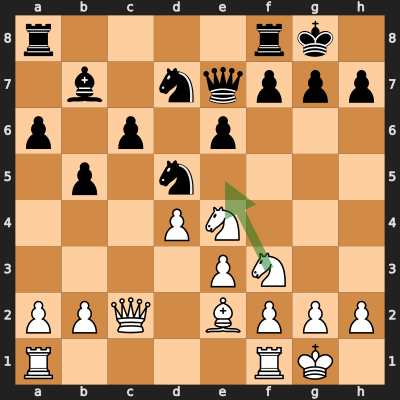

**Move:** Ne5 (`f3e5`)  
**FEN:** `r4rk1/1b1nqppp/p1p1p3/1p1n4/3PN3/4PN2/PPQ1BPPP/R4RK1 w - - 2 14`

### Stockfish Top 3

1. **Ne5** (+1.22) **(played)**  
   PV: Ne5 Nxe5 dxe5 Qc7 Nc5 Rad8 Rfd1 Bc8 Nd3 Bb7 a3 Ba8 b4 a5 Rac1 Nb6 h4 axb4 axb4 h6 f4 Nc4

2. **Rfd1** (+1.19)  
   PV: Rfd1 Rac8 Rac1 N5f6 Nc5 Nxc5 dxc5 Rcd8 b4 e5 Rxd8 Rxd8 Rd1 Rxd1+ Bxd1

3. **Rfc1** (+1.14)  
   PV: Rfc1 N5f6 Nc5 Nxc5 Qxc5 Qxc5 Rxc5 Nd7 Rc2 Rfd8 h4 h6 a3 a5 Nd2 e5 dxe5 Nxe5 Nb3 Nd7 Nd4

...

4. A piece on c5 radiates power and restricts the opponent's movements.

### Candidate Explanation
Short answer: Ne5 is a centralizing, forcing move that increases pressure on Black's cramped position and improves White's prospects either by creating a strong pawn on e5 or by exchanging Black's active pieces.

Why it makes sense (step by step):

- Immediate pressure: Nf3–e5 hits the knight on d7 and the pawn on f7. Black must decide whether to allow the knight to capture on d7 or to trade on e5.

- If Black captures (14...Nxe5), White recaptures with the d-pawn (15.dxe5). That gives White a strong pawn on e5 with useful central space; it also opens lines (the d- and f-files and diagonals) for White’s pieces and restricts Black’s knights and bishop. Even if Black later captures on e3 with the remaining knight, White recaptures with f-pawn and ends up with two central e-pawns and better activity (open f-file for the rook, plus targets on c6 and d6).

- If Black declines the capture, White can take on d7 (Nxd7) or leave a strong knight on e5 that dominates central squares (c4/d3/f3/g4) and cramps Black’s position. The knight on e5 is an excellent outpost and often forces favorable exchanges for White of Black’s well-placed minor pieces.

- Positional payoff: Ne5 either liquidates to give White a strong central pawn mass and open lines, or it keeps a dominating knight on e5 while undermining Black’s knights on d5/d7 and the weak c6 pawn. In either case White gains space, piece activity and targets to play against (c6, d6, f7).

So Ne5 is a thematic, forcing move that improves piece placement, creates a powerful e5-pawn after trades, and increases pressure on Black’s slightly awkward setup.

### Scores
**GCC: 4.94 | Precision: 2.46 (Δ -2.48) | Recall: 2.67 (Δ -2.27)**

---
## [4/5] LogicalChess_Game13

**Dobias vs Podgorny** | Prague (1952.??.??)

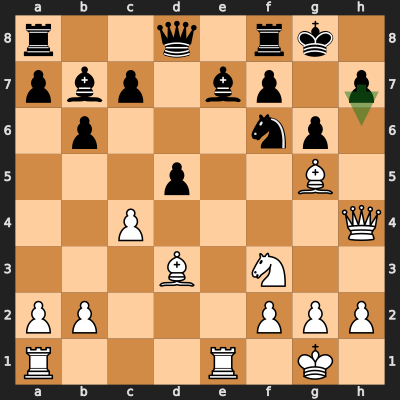

**Move:** h6 (`h7h6`)  
**FEN:** `r2q1rk1/pbp1bp1p/1p3np1/3p2B1/2P4Q/3B1N2/PP3PPP/R3R1K1 b - - 1 14`

### Stockfish Top 3

1. **Kg7** (+3.95)  
   PV: Kg7 Rxe7 Qxe7 Re1 Qd6 Bf4 Qd8 Bh6+ Kg8 Bg5 Re8 Rxe8+ Qxe8 Bxf6 dxc4 Bxc4 Bxf3 gxf3 b5 Bd5

2. **dxc4** (+4.15)  
   PV: dxc4 Bxc4 Bxf3 Rxe7 Qxe7 Bxf6 Qd6 gxf3 c5 Bc3 g5 Qxg5+ Qg6 h4 a6 Kh2 Qxg5 hxg5 b5 Bf1 c4 Bf6

3. **h6** (+4.27) **(played)**  
   PV: h6 Qxh6 Bc6 Qh4 Kg7 Rxe7 Qxe7 Re1 Qd8 Qh6+ Kg8 Ne5 Qe7 Re3 Qxe5 Rxe5 Ng4 Qh4 Rfe8 Rxe8+ Rxe8 Bf1 dxc4 Qxg4 Re1 Qc8+ Kg7

...

3. White's response with 15 Bh6+ wins the exchange.

### Candidate Explanation
This is a typical "kick / luft" pawn move on the kingside. The strategic points behind 14...h6 are:

- It immediately chases the active bishop on g5 and removes the annoying pin on Nf6. White must either exchange on f6 or retreat the bishop, and either result is good news for Black: an exchange on f6 (Bxf6 Bxf6) eliminates the pin and leaves Black with comfortable central control; a retreat (Bh4 or Be3) costs White a tempo.

- It creates a luft/escape square for the king on g8 and reduces mating/attack threats on the h7/g8 squares.

- It prepares to expand on the kingside with ...g5 (or simply ...Kg7 and ...Re8 first), gaining space and driving off White’s pieces, while at the same time freeing Black’s pieces (e.g. enabling ...Ne4 or improving the rooks).

- It is also prophylactic: it prevents White from using the g5–h6 / Qxh6 ideas that can be dangerous in some lines and forces White to make a concrete decision about the bishop.

Typical continuations show the ideas: after 14...h6 15.Bxf6 Bxf6 the pin is gone and Black recovers comfortably; after 14...h6 15.Be3 (or Bh4) Black can follow up with ...dxc4 / ...Re8 / ...Ne4 / ...Kg7 and start active play on the kingside. In short: h6 is a useful, practical move to blunt White’s pressure, gain a tempo and prepare further kingside activity.

### Scores
**GCC: 4.03 | Precision: 1.46 (Δ -2.58) | Recall: 2.23 (Δ -1.81)**

---
## [5/5] LogicalChess_Game32

**Canal vs Capablanca** | Budapest (1929.??.??)

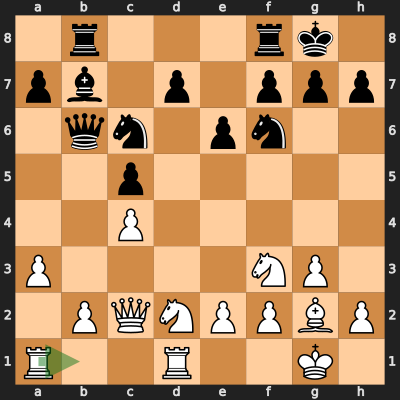

**Move:** Rab1 (`a1b1`)  
**FEN:** `1r3rk1/pb1p1ppp/1qn1pn2/2p5/2P5/P4NP1/1PQNPPBP/R2R2K1 w - - 1 13`

### Stockfish Top 3

1. **Qb3** (-0.24)  
   PV: Qb3 Ba8 Qxb6 Rxb6 b4 cxb4 axb4 Rxb4 Ne1 Nd4 Bf1 Rb7 Ra4 Rfb8 Rda1 Nc6 Nd3 Kf8 R1a3 Ke7 Ra1 Kd8 Bg2 Rc7

2. **Rab1** (-0.29) **(played)**  
   PV: Rab1 a5 b3 h6 Rb2 d6 Ne4 Nxe4 Qxe4 Qc7 Qf4 e5 Qd2 Nd4 Nxd4 exd4 Bxb7 Rxb7

3. **b3** (-0.30)  
   PV: b3 h6 Rab1 a5 Rb2 d6 Ne4 Nxe4 Qxe4 Nd4 Qd3 Nf5 Nd2 Bxg2 Kxg2 Qb7+ Kg1

...

4. The rook on b1 protects the b-pawn

5. By protecting the b-pawn, the rook relieves the queen of a responsibility

### Candidate Explanation
Rab1 is a quiet improving move with a clear queenside purpose — it activates the passive a1–rook and gets White ready to fight for the b‑file and the queenside space.

Key strategic points:

- Contest the b‑file: the rook moves from a passive square to the half‑open b‑file where Black’s queen, rook and bishop are concentrated. That increases White’s prospects of putting pressure on b7/b6 and the c5 pawn.

- Defend and prepare a pawn break: Rab1 helps protect the b2 pawn and prepares the pawn advance b2–b4 at an appropriate moment to undermine Black’s c5 pawn and dislodge the queen/rook on b6/b8. Once the b‑file is opened White’s rooks will be much more active.

- Prepare to double rooks: after Rab1 White can play Rdb1 next and double on the b‑file, maximising pressure on Black’s queenside weaknesses.

- Improve a passive piece without creating weaknesses: the a1‑rook has little scope on a1 behind a3; Rab1 redeploys it to a useful file while keeping White’s pawn structure intact.

In short: Rab1 is a preparatory, position‑building move aimed at seizing the b‑file and enabling a queenside break (b4) or doubling rooks to exploit Black’s queenside pieces.

### Scores
**GCC: 4.56 | Precision: 1.57 (Δ -2.98) | Recall: 2.09 (Δ -2.47)**

---
**Done. 5/5 entries scored.**

In [64]:
# Filtering recipes for scan DataFrame
# (run after: df = scan(n=50))
df = scan(n=5, seed=33)
# GCC says good but atoms say bad — potential GCC false positives
# gcc_mistakes = df[(df.gcc_score >= 4) & (df.atom_score <= 2)]

# Worst explanations by atom score
# wrong_expl = df[df.atom_score <= 2]

# Positions where atom extraction failed
# atom_issues = df[df.num_atoms == 0]

In [ ]:
def compare_models(entry, models=None):
    """Generate explanations with different models, score each, display side-by-side."""
    models = models or ["gpt-5-mini", "gpt-4o"]
    fen = entry["fen"]
    move_san = entry["move_san"]
    move_uci = entry["move_uci"]
    annotation = entry["annotation"]

    # Compute shared resources once
    atoms = extract_golden_atoms(annotation)
    engine_features = get_interpretable_features(fen, move_uci)
    engine_eval = get_engine_evaluation(fen, move_san)

    # Board
    board = chess.Board(fen)
    move_obj = chess.Move.from_uci(move_uci)
    svg = chess.svg.board(board, arrows=[(move_obj.from_square, move_obj.to_square)], size=400)
    display(SVG(svg))
    display(Markdown(f"**Move:** {move_san} (`{move_uci}`)  \n**FEN:** `{fen}`"))
    display(Markdown(f"### Golden Annotation\n> {annotation}"))
    display(Markdown(f"### Golden Atoms"))
    for i, atom in enumerate(atoms, 1):
        display(Markdown(f"{i}. {atom}"))

    results = []
    for model in models:
        display(Markdown(f"---\n### Model: `{model}`"))
        candidate = generate_candidate_explanation(fen, move_uci, model=model)
        display(Markdown(candidate))

        gcc_score = get_gcc_baseline_score(fen, move_san, candidate, annotation, engine_eval)
        precision = get_weighted_score(fen, move_san, candidate, atoms, engine_features, metric="Precision")
        recall = get_weighted_score(fen, move_san, candidate, atoms, engine_features, metric="Recall")
        delta_p = precision - gcc_score
        delta_r = recall - gcc_score

        display(Markdown(
            f"**GCC: {gcc_score:.2f} | Precision: {precision:.2f} (Δ {delta_p:+.2f}) | Recall: {recall:.2f} (Δ {delta_r:+.2f})**"
        ))
        results.append({
            "model": model,
            "candidate": candidate,
            "gcc_score": gcc_score,
            "precision": precision,
            "recall": recall,
            "delta_p": delta_p,
            "delta_r": delta_r,
        })

    return results

## Dataset Filtering: Optimal vs Other Moves

Split entries by whether the played move is the **top engine move** or within **10% win percentage** of it.

Win% formula (Lichess): `Win% = 50 + 50·tanh(k·cp/2)`, `k = 0.00368208`

In [9]:
import math
from tqdm.notebook import tqdm

K = 0.00368208

def cp_to_winpct(cp):
    """Lichess win% formula: Win% = 50 + 50*tanh(k*cp/2)."""
    return 50 + 50 * math.tanh(K * cp / 2)


def filter_dataset(jsonl_path, depth=20, wp_threshold=10):
    """Split dataset into optimal-move and other-move JSONL files.

    A move is 'optimal' if it is the top engine move OR the win%
    loss (from the moving side's perspective) is <= wp_threshold.
    """
    dataset = [json.loads(line) for line in open(jsonl_path)]
    base = os.path.splitext(jsonl_path)[0]
    optimal_path = f"{base}_optimal_move.jsonl"
    other_path = f"{base}_other_move.jsonl"

    optimal, other = [], []

    with chess.engine.SimpleEngine.popen_uci(STOCKFISH_PATH) as engine:
        for entry in tqdm(dataset, desc="Classifying moves"):
            fen = entry["fen"]
            move_uci = entry["move_uci"]
            board = chess.Board(fen)
            played_move = chess.Move.from_uci(move_uci)
            turn = board.turn

            # Best-move analysis
            info_best = engine.analyse(board, chess.engine.Limit(depth=depth))
            best_move = info_best["pv"][0]
            best_cp = info_best["score"].white().score(mate_score=10000)

            best_san = board.san(best_move)
            entry["best_move_uci"] = best_move.uci()
            entry["best_move_san"] = best_san

            # Played move IS the best move
            if played_move == best_move:
                entry["wp_loss"] = 0.0
                entry["is_top_engine_move"] = True
                optimal.append(entry)
                continue

            # Evaluate position after the played move
            board.push(played_move)
            info_played = engine.analyse(board, chess.engine.Limit(depth=depth))
            played_cp = info_played["score"].white().score(mate_score=10000)

            best_wp = cp_to_winpct(best_cp)
            played_wp = cp_to_winpct(played_cp)

            # Win% loss from the moving side's perspective
            if turn == chess.WHITE:
                wp_loss = best_wp - played_wp
            else:
                wp_loss = played_wp - best_wp

            entry["wp_loss"] = round(wp_loss, 2)
            entry["is_top_engine_move"] = False

            if wp_loss <= wp_threshold:
                optimal.append(entry)
            else:
                other.append(entry)

    # Write output files
    with open(optimal_path, "w") as f:
        for e in optimal:
            f.write(json.dumps(e) + "\n")

    with open(other_path, "w") as f:
        for e in other:
            f.write(json.dumps(e) + "\n")

    print(f"Optimal: {len(optimal)} | Other: {len(other)} | Total: {len(dataset)}")
    print(f"  -> {optimal_path}")
    print(f"  -> {other_path}")
    return optimal, other

In [10]:
optimal, other = filter_dataset(JSONL_PATH, depth=20)

Classifying moves:   0%|          | 0/1832 [00:00<?, ?it/s]

Optimal: 1775 | Other: 57 | Total: 1832
  -> ../logical_chess_optimal_move.jsonl
  -> ../logical_chess_other_move.jsonl
